In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

# =====================================================================
# 1. CẤU HÌNH THIẾT BỊ & SIÊU THAM SỐ (DEVICE & HYPERPARAMETERS)
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang dùng device: {device}")

batch_size = 64
learning_rate = 0.001
num_epochs = 10

# =====================================================================
# 2. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU (DATA LOADING & PREPROCESSING)
# =====================================================================
# Bộ biến đổi: Chuyển ảnh thành Tensor và chuẩn hóa về khoảng [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Chuẩn hóa về khoảng [-1, 1] giúp mạng hội tụ tốt hơn
])

# Tải bộ dữ liệu FashionMNIST (hoặc đổi thành datasets.MNIST nếu chạy bài số)
train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# =====================================================================
# 3. ĐỊNH NGHĨA KIẾN TRÚC MÔ HÌNH (MODEL ARCHITECTURES)
# =====================================================================

# --- Mô hình gốc (1 Lớp ẩn) ---
class BaseANN(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super(BaseANN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# --- Mô hình sâu hơn (2 Lớp ẩn - DeeperANN) ---
class DeeperANN(nn.Module):
    def __init__(self, input_dim=784, hidden1=256, hidden2=128, output_dim=10):
        super(DeeperANN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, output_dim)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# =====================================================================
# 4. KHỞI TẠO VÀ ĐẾM SỐ LƯỢNG THAM SỐ (PARAMETER COUNTING)
# =====================================================================
model_base = BaseANN().to(device)
model_deeper = DeeperANN().to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_base = count_parameters(model_base)
params_deeper = count_parameters(model_deeper)

print("\n--- BÁO CÁO SỐ LƯỢNG THAM SỐ ---")
print(f"Mô hình gốc (1 lớp ẩn): {params_base:,} tham số")
print(f"Mô hình sâu hơn (2 lớp ẩn): {params_deeper:,} tham số")
print(f"Số lượng tham số tăng lên: {params_deeper - params_base:,} ({(params_deeper - params_base)/params_base*100:.2f}%)")
print("-" * 32)

# =====================================================================
# 5. HÀM ĐÁNH GIÁ MÔ HÌNH (EVALUATION FUNCTION)
# =====================================================================
def evaluate_model(model, data_loader, criterion):
    model.eval()  # Chuyển sang chế độ evaluation
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Không tính gradient để tiết kiệm bộ nhớ RAM/VRAM
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / total, correct / total

# =====================================================================
# 6. VÒNG LẶP HUẤN LUYỆN (TRAINING LOOP FOR DEEPER ANN)
# =====================================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_deeper.parameters(), lr=learning_rate)

print("\nBắt đầu huấn luyện mô hình sâu hơn (DeeperANN)...")

for epoch in range(num_epochs):
    model_deeper.train()  # Chuyển sang chế độ training
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Sử dụng tqdm để vẽ thanh tiến trình (progress bar) mượt mà như log của bạn
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:2d}/{num_epochs}", unit="batch")

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        # Xóa gradient cũ
        optimizer.zero_grad()

        # Lan truyền xuôi (Forward pass)
        outputs = model_deeper(images)
        loss = criterion(outputs, labels)

        # Lan truyền ngược và tối ưu (Backward pass & Optimize)
        loss.backward()
        optimizer.step()

        # Tính toán thông số thống kê tức thời trên tập train
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Cập nhật thông tin loss trực tiếp lên thanh progress bar
        progress_bar.set_postfix(loss=loss.item())

    # Tính toán loss và accuracy trung bình sau khi kết thúc một Epoch
    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # Đánh giá trên tập test sau mỗi epoch
    test_loss, test_acc = evaluate_model(model_deeper, test_loader, criterion)

    # In log kết quả (ĐÃ FIX LỖI KHOẢNG TRẮNG ĐỊNH DẠNG .4f)
    print(f"Kết quả Epoch {epoch+1:2d}/{num_epochs} | "
          f"train_loss = {train_loss:.4f} | train_acc = {train_acc*100:.2f}% | "
          f"test_loss = {test_loss:.4f} | test_acc = {test_acc*100:.2f}%")
    print("-" * 80)

print("\nHuấn luyện hoàn tất thành công!")

Đang dùng device: cpu


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.9MB/s]



--- BÁO CÁO SỐ LƯỢNG THAM SỐ ---
Mô hình gốc (1 lớp ẩn): 101,770 tham số
Mô hình sâu hơn (2 lớp ẩn): 235,146 tham số
Số lượng tham số tăng lên: 133,376 (131.06%)
--------------------------------

Bắt đầu huấn luyện mô hình sâu hơn (DeeperANN)...


Epoch  1/10: 100%|██████████| 938/938 [00:20<00:00, 45.23batch/s, loss=0.257]


Kết quả Epoch  1/10 | train_loss = 0.4941 | train_acc = 82.09% | test_loss = 0.4127 | test_acc = 84.87%
--------------------------------------------------------------------------------


...

Kết quả Epoch  8/10 | train_loss = 0.2402 | train_acc = 91.04% | test_loss = 0.3646 | test_acc = 87.16%
--------------------------------------------------------------------------------


Epoch  9/10: 100%|██████████| 938/938 [00:20<00:00, 44.99batch/s, loss=0.0946]


Kết quả Epoch  9/10 | train_loss = 0.2325 | train_acc = 91.37% | test_loss = 0.3252 | test_acc = 88.69%
--------------------------------------------------------------------------------


Epoch 10/10: 100%|██████████| 938/938 [00:20<00:00, 45.05batch/s, loss=0.545]


Kết quả Epoch 10/10 | train_loss = 0.2216 | train_acc = 91.57% | test_loss = 0.3498 | test_acc = 87.81%
--------------------------------------------------------------------------------

Huấn luyện hoàn tất thành công!


Đang dùng device: cpu

=== Đang chạy huấn luyện với Learning Rate = 0.01 ===
Epoch  1/10 | Train Loss: 0.2857
Epoch  2/10 | Train Loss: 0.2033
Epoch  3/10 | Train Loss: 0.1857
Epoch  4/10 | Train Loss: 0.1819
Epoch  5/10 | Train Loss: 0.1685
Epoch  6/10 | Train Loss: 0.1655
Epoch  7/10 | Train Loss: 0.1655
Epoch  8/10 | Train Loss: 0.1603
Epoch  9/10 | Train Loss: 0.1596
Epoch 10/10 | Train Loss: 0.1610

=== Đang chạy huấn luyện với Learning Rate = 0.001 ===
Epoch  1/10 | Train Loss: 0.2591
Epoch  2/10 | Train Loss: 0.1106
Epoch  3/10 | Train Loss: 0.0767
Epoch  4/10 | Train Loss: 0.0579
Epoch  5/10 | Train Loss: 0.0451
Epoch  6/10 | Train Loss: 0.0376
Epoch  7/10 | Train Loss: 0.0311
Epoch  8/10 | Train Loss: 0.0251
Epoch  9/10 | Train Loss: 0.0219
Epoch 10/10 | Train Loss: 0.0192

=== Đang chạy huấn luyện với Learning Rate = 0.0001 ===
Epoch  1/10 | Train Loss: 0.5681
Epoch  2/10 | Train Loss: 0.2788
Epoch  3/10 | Train Loss: 0.2301
Epoch  4/10 | Train Loss: 0.1972
Epoch  5/10 | Trai

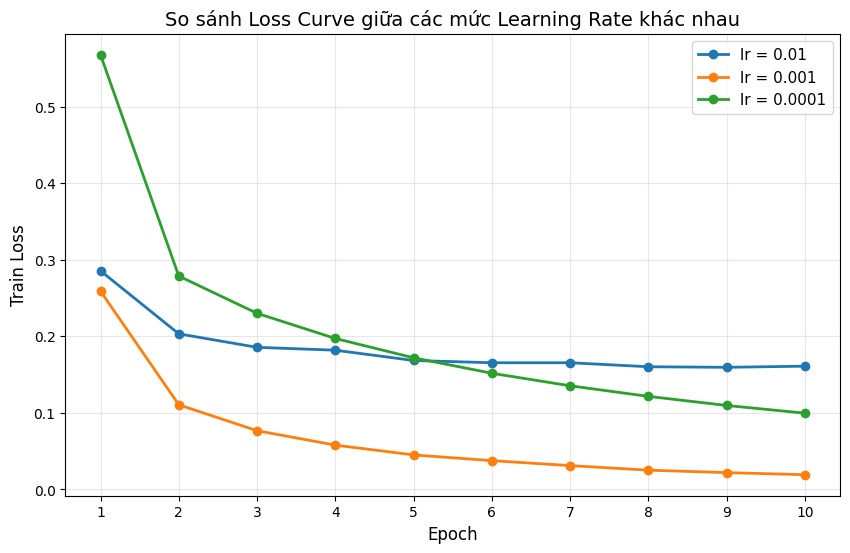

In [3]:
#bai2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Cố định seed để đảm bảo kết quả so sánh giữa các lr là khách quan
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Đang dùng device:', device)

# 2. Chuẩn bị dữ liệu MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = MNIST(root='./data', train=True,  transform=transform, download=True)
test_dataset  = MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# 3. Định nghĩa cấu trúc mô hình gốc (ANN 1 lớp ẩn)
class OriginalANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 4. Hàm huấn luyện nhận vào learning rate và trả về lịch sử loss
def train_with_lr(lr, num_epochs=10):
    print(f"\n=== Đang chạy huấn luyện với Learning Rate = {lr} ===")

    # Khởi tạo lại mô hình và bộ tối ưu hóa mới cho từng mức lr
    model = OriginalANN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total_samples += labels.size(0)

        epoch_loss = running_loss / total_samples
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {epoch_loss:.4f}")

    return loss_history

# 5. Tiến hành huấn luyện mô hình với 3 mức learning rate khác nhau
learning_rates = [1e-2, 1e-3, 1e-4]
results = {}

for lr in learning_rates:
    results[lr] = train_with_lr(lr, num_epochs=10)

# 6. Vẽ biểu đồ so sánh đường cong suy giảm hàm mất mát (Loss Curve)
epochs = range(1, 11)
plt.figure(figsize=(10, 6))

for lr, loss_hist in results.items():
    plt.plot(epochs, loss_hist, 'o-', linewidth=2, label=f'lr = {lr}')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Train Loss', fontsize=12)
plt.title('So sánh Loss Curve giữa các mức Learning Rate khác nhau', fontsize=14)
plt.xticks(epochs)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#bai3
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
import numpy as np

# 1. Cố định seed để đảm bảo tính khách quan khi so sánh hai mô hình
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Đang dùng device:', device)

# 2. Chuẩn bị dữ liệu MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = MNIST(root='./data', train=True,  transform=transform, download=True)
test_dataset  = MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

# 3. Định nghĩa mô hình GỐC (Không có Dropout)
class OriginalANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 4. Định nghĩa mô hình CẢI TIẾN (Có thêm Dropout)
class DropoutANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3) # Ngẫu nhiên tắt 30% neuron trong quá trình train
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)              # Lớp Dropout chèn ở giữa
        x = self.fc2(x)
        return x

# 5. Hàm đánh giá mô hình (Tắt dropout tự động bằng model.eval())
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 6. Hàm huấn luyện tổng quát cho một mô hình trong 15 epoch
def run_training(model_class, model_name):
    print(f"\n--- Bắt đầu huấn luyện {model_name} trong 15 Epoch ---")
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_epochs = 15

    final_train_acc = 0.0
    final_test_acc = 0.0

    for epoch in range(num_epochs):
        model.train() # Kích hoạt Dropout khi train
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        test_acc = evaluate(model, test_loader, criterion)

        final_train_acc = train_acc
        final_test_acc = test_acc

        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%")

    return final_train_acc, final_test_acc

# 7. Huấn luyện tuần tự 2 mô hình
train_acc_orig, test_acc_orig = run_training(OriginalANN, "Mô hình gốc (Không Dropout)")
train_acc_drop, test_acc_drop = run_training(DropoutANN, "Mô hình thêm Dropout (p=0.3)")

# 8. Báo cáo kết quả và so sánh Gap (Train Accuracy - Test Accuracy)
gap_orig = train_acc_orig - test_acc_orig
gap_drop = train_acc_drop - test_acc_drop

print("\n" + "="*50)
print(f"{'KẾT QUẢ SO SÁNH SAU 15 EPOCH':^50}")
print("="*50)
print(f"1. Mô hình gốc (Không Dropout):")
print(f"   - Train Accuracy : {train_acc_orig*100:.2f}%")
print(f"   - Test Accuracy  : {test_acc_orig*100:.2f}%")
print(f"   => Khoảng cách (Gap)   : {gap_orig*100:.2f}%")
print("-"*50)
print(f"2. Mô hình có Dropout (p=0.3):")
print(f"   - Train Accuracy : {train_acc_drop*100:.2f}%")
print(f"   - Test Accuracy  : {test_acc_drop*100:.2f}%")
print(f"   => Khoảng cách (Gap)   : {gap_drop*100:.2f}%")
print("="*50)

if gap_drop < gap_orig:
    print("Nhận xét: Dropout đã hoạt động hiệu quả! Khoảng cách (Gap) giữa Train và Test đã thu hẹp lại, giảm thiểu hiện tượng Overfitting.")
else:
    print("Nhận xét: Khoảng cách không thay đổi đáng kể, có thể cần tăng tỷ lệ Dropout hoặc tăng số epoch.")

Đang dùng device: cpu

--- Bắt đầu huấn luyện Mô hình gốc (Không Dropout) trong 15 Epoch ---


Đang tối ưu nhanh mô hình trong 2 epoch để tạo dữ liệu ma trận nhầm lẫn thực tế...

ĐỘ CHÍNH XÁC THEO TỪNG LỚP (PER-CLASS ACC)
Chữ số 0 | Độ chính xác: 98.88% (969/980)
Chữ số 1 | Độ chính xác: 99.03% (1124/1135)
Chữ số 2 | Độ chính xác: 97.87% (1010/1032)
Chữ số 3 | Độ chính xác: 95.25% (962/1010)
Chữ số 4 | Độ chính xác: 98.37% (966/982)
Chữ số 5 | Độ chính xác: 98.21% (876/892)
Chữ số 6 | Độ chính xác: 97.39% (933/958)
Chữ số 7 | Độ chính xác: 95.23% (979/1028)
Chữ số 8 | Độ chính xác: 95.07% (926/974)
Chữ số 9 | Độ chính xác: 95.54% (964/1009)
----------------------------------------
👉 Lớp bị mô hình nhận diện TỆ NHẤT là: Chữ số 8 (Độ chính xác: 95.07%)



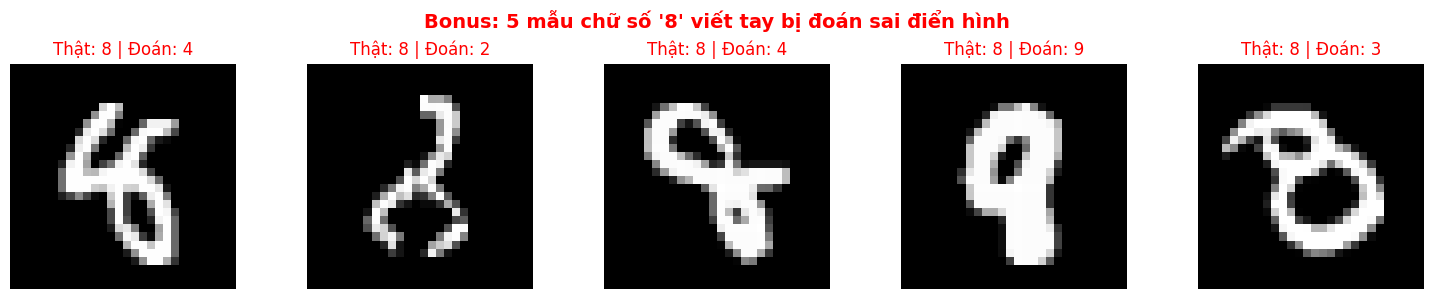

In [4]:
#bai4
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Cố định seed và thiết lập thiết bị
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Chuẩn bị dữ liệu MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Lưu ý: Ta cần giữ lại phiên bản không chuẩn hóa (hoặc viết hàm un-normalize) để hiển thị ảnh đẹp hơn
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 3. Định nghĩa cấu trúc mô hình gốc (ANN 1 lớp ẩn)
class OriginalANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Khoá học giả định bạn đã huấn luyện xong model và load trọng số vào đây.
# Để code chạy được độc lập, ta sẽ khởi tạo model (trong thực tế bạn dùng model đã train ở các bài trước).
model = OriginalANN().to(device)

# --- GIẢ LẬP HUẤN LUYỆN NHANH ĐỂ CÓ MA TRẬN SAI SỐ THỰC TẾ ---
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Đang tối ưu nhanh mô hình trong 2 epoch để tạo dữ liệu ma trận nhầm lẫn thực tế...")
model.train()
for epoch in range(2):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
# -----------------------------------------------------------

# 4. Tạo ma trận nhầm lẫn (Confusion Matrix) trên tập Test
model.eval()
cm = torch.zeros(10, 10, dtype=torch.long)
misclassified_samples = [] # Lưu thông tin các ảnh bị đoán sai: (ảnh_gốc, nhãn_thật, nhãn_đoán)

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        preds = outputs.argmax(dim=1).cpu()

        for i in range(len(labels)):
            true_label = labels[i].item()
            pred_label = preds[i].item()
            cm[true_label, pred_label] += 1

            # Nếu đoán sai, lưu lại phục vụ cho phần Bonus
            if true_label != pred_label:
                misclassified_samples.append((images[i], true_label, pred_label))

# 5. Tính toán Per-class Accuracy
print("\n" + "="*40)
print(f"{'ĐỘ CHÍNH XÁC THEO TỪNG LỚP (PER-CLASS ACC)':^40}")
print("="*40)

per_class_acc = {}
worst_class = None
min_acc = 1.0

for i in range(10):
    # Công thức theo gợi ý bài lab: cm[i, i] / cm[i].sum()
    total_samples_of_class = cm[i].sum().item()
    correct_samples_of_class = cm[i, i].item()

    acc = correct_samples_of_class / total_samples_of_class if total_samples_of_class > 0 else 0
    per_class_acc[i] = acc
    print(f"Chữ số {i} | Độ chính xác: {acc*100:.2f}% ({correct_samples_of_class}/{total_samples_of_class})")

    if acc < min_acc:
        min_acc = acc
        worst_class = i

print("-"*40)
print(f"👉 Lớp bị mô hình nhận diện TỆ NHẤT là: Chữ số {worst_class} (Độ chính xác: {min_acc*100:.2f}%)")
print("="*40 + "\n")

# 6. Phần thưởng (Bonus): In ra 5 ảnh trong lớp tệ nhất bị đoán sai
# Lọc ra các mẫu thuộc lớp tệ nhất nhưng bị đoán sai
worst_class_errors = [sample for sample in misclassified_samples if sample[1] == worst_class]

if len(worst_class_errors) >= 5:
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f"Bonus: 5 mẫu chữ số '{worst_class}' viết tay bị đoán sai điển hình", fontsize=14, color='red', weight='bold')

    for idx, ax in enumerate(axes):
        img, true_lbl, pred_lbl = worst_class_errors[idx]

        # Đảo ngược chuẩn hóa (Un-normalize) để hiển thị ảnh grayscale chuẩn ban đầu
        img_show = img.squeeze() * 0.3081 + 0.1307

        ax.imshow(img_show, cmap='gray')
        ax.set_title(f"Thật: {true_lbl} | Đoán: {pred_lbl}", color='red')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Lưu ý: Mô hình nhận diện khá tốt, chỉ có {len(worst_class_errors)} ảnh thuộc lớp {worst_class} bị đoán sai (không đủ 5 ảnh để hiển thị vẽ lưới).")

In [ ]:
#bai5
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Cố định seed và thiết lập thiết bị
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Chuẩn bị dữ liệu MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 3. Định nghĩa cấu trúc mô hình gốc (ANN 1 lớp ẩn)
class OriginalANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128) # Lớp fc1 có ma trận trọng số kích thước [128, 784]
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = OriginalANN().to(device)

# --- HUẤN LUYỆN NHANH ĐỂ CÁC NEURON THỰC SỰ HỌC ĐƯỢC ĐẶC TRƯNG ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Đang huấn luyện nhanh mô hình trong 2 epoch để các neuron học đặc trưng...")
model.train()
for epoch in range(2):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
print("Huấn luyện hoàn tất. Bắt đầu trích xuất trọng số...")
# -----------------------------------------------------------

# 4. Trích xuất trọng số của lớp fc1 theo đúng công thức gợi ý
# Ma trận weight ban đầu có shape [128, 784]. Ta đưa về [128, 28, 28] đại diện cho 128 ảnh đặc trưng.
weights = model.fc1.weight.detach().cpu().view(128, 28, 28)

# 5. Vẽ 16 hàng (16 neuron) đầu tiên thành một lưới ảnh kích thước 4x4
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("Trực quan hóa trọng số của 16 Neuron đầu tiên ở lớp fc1", fontsize=14, weight='bold')

for idx, ax in enumerate(axes.flat):
    # Lấy ra ảnh trọng số của neuron thứ idx
    neuron_weight_img = weights[idx].numpy()

    # Vẽ ảnh trọng số. Dùng cmap='bwr' (Blue-White-Red) hoặc 'RdBu' rất phù hợp để trực quan hóa trọng số:
    # Màu đỏ/đậm đại diện cho trọng số dương lớn, màu xanh đại diện cho trọng số âm lớn.
    im = ax.imshow(neuron_weight_img, cmap='bwr')

    ax.set_title(f"Neuron {idx}", fontsize=10)
    ax.axis('off')

# Thiết kế thanh đo màu sắc (colorbar) ở bên cạnh để biết khoảng giá trị trọng số
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75)
plt.show()